# Corpus Cleanup via Self-Consistency

Идея: применить classifier ко **всем 400 pages** corpus, посчитать per-page compression, и **отбросить pages с extreme compression** как не-article-style.

- **Compression > 90%** → почти всё удалено → page не article (portal, dashboard, directory)
- **Compression < 5%** → почти ничего не удалено → page тоже не article (interactive UI, code review, raw data)
- **5% ≤ compression ≤ 90%** → классификатор уверенно работает → реально article-style

После cleanup:
- Recompute aggregate compression на «cleaned» subset
- Recompute F1 на test subset
- Показать какие pages удалены и их topics — sanity check

In [18]:
import json
import sys
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, '.')
import filter_apply as fa
import filter_visualize as fv

import importlib
importlib.reload(fa)
importlib.reload(fv)

FIGURES_DIR = Path('figures') / 'cleanup'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import train_lib
import importlib
importlib.reload(train_lib)

<module 'train_lib' from 'c:\\Users\\70133\\VS_Code_Projects\\jarvis-core\\notebooks\\webui\\training\\train_lib.py'>

## 1. Train best model + load splits

In [19]:
model, artifacts = fa.train_best_model()

with open(fa.DATA_DIR / 'splits.json', encoding='utf-8') as f:
    splits_data = json.load(f)
splits = splits_data['splits']
topic_map = splits_data['page_topic']

candidates_by_page = fa.load_candidates_index()
all_pages = sorted(candidates_by_page.keys())
print(f'Total pages in corpus: {len(all_pages)}')

Loading train features...
X_train shape: (4385, 20031), y_train: junk=1816/4385
Model trained.
Total pages in corpus: 400


## 2. Predict on ALL corpus pages (5–10 минут)

In [20]:
import time

all_results = []
t0 = time.time()
for i, pid in enumerate(all_pages):
    page_cands = candidates_by_page.get(pid, [])
    if not page_cands:
        continue
    preds = fa.predict_for_page(page_cands, model, artifacts)
    ax_data = fa.load_page_axtree(pid)
    if ax_data is None:
        continue
    comp = fa.compute_compression(preds, ax_data)
    all_results.append({
        'page_id': pid,
        'topic': topic_map.get(pid, 'unknown'),
        'split': splits.get(pid, 'unknown'),
        'compression_ratio': comp['compression_ratio'],
        'n_total_nodes': comp['n_total_nodes'],
        'n_removed_nodes': comp['n_removed_nodes'],
        'n_kept_nodes': comp['n_kept_nodes'],
        'n_junk_candidates': comp['n_junk_candidates'],
        'n_total_candidates': comp['n_total_candidates'],
    })
    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'  [{i+1}/{len(all_pages)}] elapsed {elapsed:.0f}s')

print(f'\nProcessed {len(all_results)} pages in {time.time()-t0:.0f}s')

# Save raw
with open(FIGURES_DIR / 'all_pages_compression.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

  [50/400] elapsed 1s
  [100/400] elapsed 2s
  [150/400] elapsed 3s
  [200/400] elapsed 4s
  [250/400] elapsed 5s
  [300/400] elapsed 6s
  [350/400] elapsed 7s
  [400/400] elapsed 8s

Processed 400 pages in 8s


## 3. Compression distribution на ВСЕМ corpus

=== Compression on all 400 corpus pages ===
  Mean: 41.0%
  Median: 37.3%
  Std: 30.6%

  >= 99% compression: 15 pages
  >= 90% compression: 43 pages
  >= 80% compression: 61 pages
  <= 5% compression: 57 pages
  <= 10% compression: 79 pages


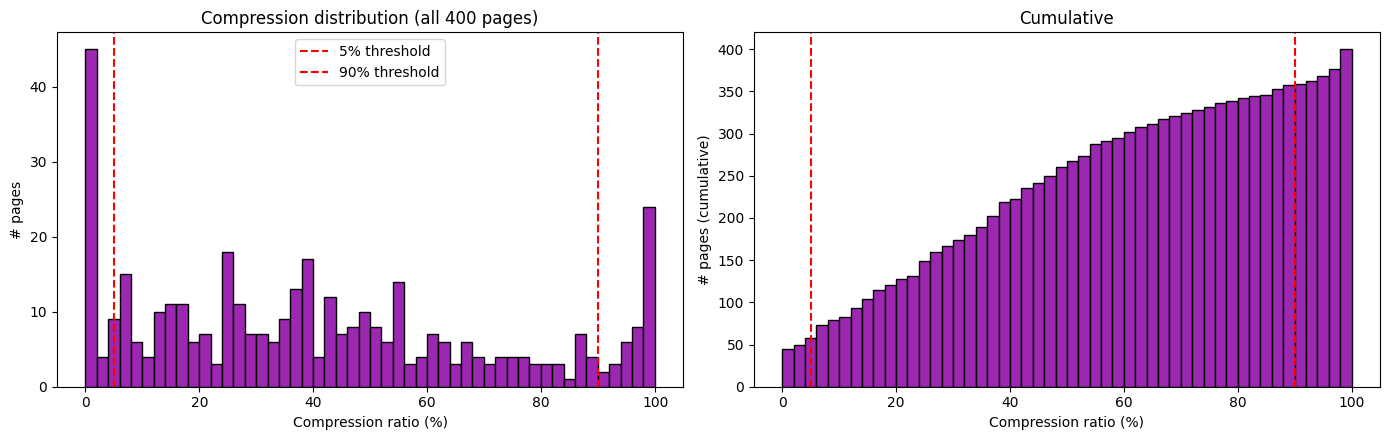

In [21]:
ratios = np.array([r['compression_ratio'] for r in all_results])
topics = [r['topic'] for r in all_results]

print(f'=== Compression on all {len(all_results)} corpus pages ===')
print(f'  Mean: {ratios.mean()*100:.1f}%')
print(f'  Median: {np.median(ratios)*100:.1f}%')
print(f'  Std: {ratios.std()*100:.1f}%')
print()
print(f'  >= 99% compression: {(ratios >= 0.99).sum()} pages')
print(f'  >= 90% compression: {(ratios >= 0.90).sum()} pages')
print(f'  >= 80% compression: {(ratios >= 0.80).sum()} pages')
print(f'  <= 5% compression: {(ratios <= 0.05).sum()} pages')
print(f'  <= 10% compression: {(ratios <= 0.10).sum()} pages')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(ratios * 100, bins=50, color='#9c27b0', edgecolor='black')
axes[0].axvline(5, color='red', linestyle='--', label='5% threshold')
axes[0].axvline(90, color='red', linestyle='--', label='90% threshold')
axes[0].set_xlabel('Compression ratio (%)')
axes[0].set_ylabel('# pages')
axes[0].set_title(f'Compression distribution (all {len(ratios)} pages)')
axes[0].legend()

axes[1].hist(ratios * 100, bins=50, color='#9c27b0', edgecolor='black', cumulative=True)
axes[1].set_xlabel('Compression ratio (%)')
axes[1].set_ylabel('# pages (cumulative)')
axes[1].set_title('Cumulative')
axes[1].axvline(5, color='red', linestyle='--')
axes[1].axvline(90, color='red', linestyle='--')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'compression_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Threshold sweep — где optimum

In [22]:
thresholds = [
    (0.00, 1.00, 'no filter'),
    (0.01, 0.99, '1%-99%'),
    (0.05, 0.90, '5%-90% (proposed)'),
    (0.05, 0.85, '5%-85%'),
    (0.10, 0.80, '10%-80%'),
    (0.05, 0.95, '5%-95%'),
]

print(f'{"threshold":<22s} {"n_kept":>8s} {"n_dropped":>10s} {"mean_comp":>11s} {"med_comp":>10s}')
for low, high, name in thresholds:
    mask = (ratios >= low) & (ratios <= high)
    kept_ratios = ratios[mask]
    if len(kept_ratios) == 0:
        continue
    print(f'{name:<22s} {mask.sum():>8d} {(~mask).sum():>10d} '
          f'{kept_ratios.mean()*100:>10.1f}% {np.median(kept_ratios)*100:>9.1f}%')

threshold                n_kept  n_dropped   mean_comp   med_comp
no filter                   400          0       41.0%      37.3%
1%-99%                      343         57       43.5%      38.9%
5%-90% (proposed)           300        100       40.5%      38.6%
5%-85%                      289        111       38.7%      37.6%
10%-80%                     260        140       40.2%      38.7%
5%-95%                      308         92       41.9%      38.8%


## 5. Apply 5%-90% filter — какие pages выкидываем

Sanity check: должны быть pages типа login forms, dashboards, code review — non-article.

In [23]:
LOW = 0.05
HIGH = 0.90

kept = [r for r in all_results if LOW <= r['compression_ratio'] <= HIGH]
dropped = [r for r in all_results if r['compression_ratio'] < LOW or r['compression_ratio'] > HIGH]

print(f'=== Cleanup with thresholds [{LOW*100:.0f}%, {HIGH*100:.0f}%] ===')
print(f'  Kept: {len(kept)} pages ({len(kept)/len(all_results)*100:.1f}%)')
print(f'  Dropped: {len(dropped)} pages ({len(dropped)/len(all_results)*100:.1f}%)')

# Topic distribution of dropped
dropped_topic_high = Counter(r['topic'] for r in dropped if r['compression_ratio'] > HIGH)
dropped_topic_low = Counter(r['topic'] for r in dropped if r['compression_ratio'] < LOW)
kept_topic = Counter(r['topic'] for r in kept)

print(f'\n  Dropped (compression > {HIGH*100:.0f}%) — likely portal/dashboard pages:')
for t, n in dropped_topic_high.most_common():
    print(f'    {t}: {n}')

print(f'\n  Dropped (compression < {LOW*100:.0f}%) — likely interactive UI / non-article:')
for t, n in dropped_topic_low.most_common():
    print(f'    {t}: {n}')

print(f'\n  Kept topic distribution:')
for t, n in kept_topic.most_common():
    print(f'    {t}: {n}')

=== Cleanup with thresholds [5%, 90%] ===
  Kept: 300 pages (75.0%)
  Dropped: 100 pages (25.0%)

  Dropped (compression > 90%) — likely portal/dashboard pages:
    tutorial: 16
    news: 9
    bare: 5
    terms: 4
    unknown: 4
    list: 3
    other: 2

  Dropped (compression < 5%) — likely interactive UI / non-article:
    unknown: 24
    tutorial: 16
    terms: 7
    list: 6
    news: 3
    bare: 1

  Kept topic distribution:
    tutorial: 119
    news: 67
    terms: 45
    list: 40
    unknown: 20
    bare: 5
    other: 4


## 6. Compression by split — было vs стало

In [24]:
for split_name in ['train', 'val', 'test']:
    pre = [r for r in all_results if r['split'] == split_name]
    post = [r for r in kept if r['split'] == split_name]
    if not pre:
        continue
    pre_ratios = [r['compression_ratio'] for r in pre]
    post_ratios = [r['compression_ratio'] for r in post]
    print(f'  {split_name}: {len(pre)} → {len(post)} pages '
          f'(mean compression: {np.mean(pre_ratios)*100:.1f}% → {np.mean(post_ratios)*100:.1f}%, '
          f'median: {np.median(pre_ratios)*100:.1f}% → {np.median(post_ratios)*100:.1f}%)')

  train: 278 → 218 pages (mean compression: 41.8% → 38.8%, median: 37.9% → 37.0%)
  val: 32 → 26 pages (mean compression: 44.6% → 43.5%, median: 38.9% → 38.9%)
  test: 42 → 36 pages (mean compression: 40.5% → 36.3%, median: 36.9% → 32.8%)


## 7. Re-evaluate test F1 on cleaned subset

Берём test pages только из «cleaned» subset (5%–90% compression) и считаем F1.

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score
from train_lib import load_split, assemble_features, binary_y, filter_labels

# Load test split features
test_data = load_split('test')
test_pages_kept = {r['page_id'] for r in kept if r['split'] == 'test'}
test_pages_dropped = {r['page_id'] for r in all_results if r['split'] == 'test' and r['page_id'] not in test_pages_kept}

print(f'Test pages: {sum(1 for r in all_results if r["split"] == "test")} total')
print(f'  Kept after cleanup: {len(test_pages_kept)}')
print(f'  Dropped after cleanup: {len(test_pages_dropped)}')

# Build feature matrix for test
test_keep_idx = filter_labels(test_data, exclude_skip=True)
test_kept_meta = [test_data['labels'][i] for i in test_keep_idx]
y_test = binary_y(test_kept_meta)

from scipy.sparse import csr_matrix, hstack
geo = test_data['geometric'][test_keep_idx]
struct = test_data['structural'][test_keep_idx]
rec = test_data['recurrence'][test_keep_idx]
role = test_data['role_onehot'][test_keep_idx]
dense = np.hstack([geo, struct, rec, role]).astype(np.float32)
X_test = hstack([test_data['word_tfidf'][test_keep_idx], test_data['char_tfidf'][test_keep_idx], csr_matrix(dense)]).tocsr()

y_pred_full = model.predict(X_test)
y_proba_full = model.predict_proba(X_test)[:, 1]

# All test
f1_all = f1_score(y_test, y_pred_full, zero_division=0)
p_all = precision_score(y_test, y_pred_full, zero_division=0)
r_all = recall_score(y_test, y_pred_full, zero_division=0)

# Cleaned subset (only candidates from kept pages)
cleaned_idx = [i for i, m in enumerate(test_kept_meta) if str(m['page_id']) in test_pages_kept]
y_test_cl = y_test[cleaned_idx]
y_pred_cl = y_pred_full[cleaned_idx]
f1_cl = f1_score(y_test_cl, y_pred_cl, zero_division=0)
p_cl = precision_score(y_test_cl, y_pred_cl, zero_division=0)
r_cl = recall_score(y_test_cl, y_pred_cl, zero_division=0)

# Gold-only on each
gold_idx_all = [i for i, m in enumerate(test_kept_meta) if m.get('label_source') == 'human']
y_test_gold = y_test[gold_idx_all]
y_pred_gold = y_pred_full[gold_idx_all]
f1_gold_all = f1_score(y_test_gold, y_pred_gold, zero_division=0)

gold_idx_cl = [i for i in cleaned_idx if test_kept_meta[i].get('label_source') == 'human']
y_test_gold_cl = y_test[gold_idx_cl]
y_pred_gold_cl = y_pred_full[gold_idx_cl]
f1_gold_cl = f1_score(y_test_gold_cl, y_pred_gold_cl, zero_division=0) if len(gold_idx_cl) > 0 else None

print()
print(f'=== F1 comparison: full test vs cleaned subset ===')
print(f'                        full ({len(y_test)})       cleaned ({len(y_test_cl)})')
print(f'  F1 (mixed)            {f1_all:.3f}             {f1_cl:.3f}')
print(f'  Precision (mixed)     {p_all:.3f}             {p_cl:.3f}')
print(f'  Recall (mixed)        {r_all:.3f}             {r_cl:.3f}')
print(f'  F1 (gold)             {f1_gold_all:.3f}             {f1_gold_cl if f1_gold_cl is not None else "N/A"}')

Test pages: 42 total
  Kept after cleanup: 36
  Dropped after cleanup: 6

=== F1 comparison: full test vs cleaned subset ===
                        full (723)       cleaned (677)
  F1 (mixed)            0.824             0.813
  Precision (mixed)     0.827             0.819
  Recall (mixed)        0.821             0.808
  F1 (gold)             0.838             0.8356164383561644


## 8. Final corpus statistics (after cleanup)

In [26]:
kept_total_nodes = sum(r['n_total_nodes'] for r in kept)
kept_removed = sum(r['n_removed_nodes'] for r in kept)
kept_kept_nodes = sum(r['n_kept_nodes'] for r in kept)

print(f'=== Final corpus after cleanup ===')
print(f'  Pages: {len(kept)} (was {len(all_results)})')
print(f'  Total AXTree nodes (input): {kept_total_nodes}')
print(f'  Removed by classifier: {kept_removed} ({kept_removed/kept_total_nodes*100:.1f}%)')
print(f'  Kept (final widget tree input): {kept_kept_nodes}')
print(f'  Avg nodes/page after filtering: {kept_kept_nodes/len(kept):.1f}')
print(f'  Avg compression: {np.mean([r["compression_ratio"] for r in kept])*100:.1f}%')

# Save final stats
final_stats = {
    'thresholds': {'low': LOW, 'high': HIGH},
    'pages_before': len(all_results),
    'pages_after': len(kept),
    'pages_dropped_high': sum(1 for r in dropped if r['compression_ratio'] > HIGH),
    'pages_dropped_low': sum(1 for r in dropped if r['compression_ratio'] < LOW),
    'mean_compression_after': float(np.mean([r['compression_ratio'] for r in kept])),
    'avg_nodes_per_page_after': kept_kept_nodes / len(kept),
    'f1_full_test_mixed': float(f1_all),
    'f1_cleaned_test_mixed': float(f1_cl),
    'f1_full_test_gold': float(f1_gold_all),
    'f1_cleaned_test_gold': float(f1_gold_cl) if f1_gold_cl is not None else None,
    'dropped_topic_high': dict(dropped_topic_high),
    'dropped_topic_low': dict(dropped_topic_low),
    'kept_topic': dict(kept_topic),
}
with open(FIGURES_DIR / 'cleanup_stats.json', 'w', encoding='utf-8') as f:
    json.dump(final_stats, f, ensure_ascii=False, indent=2)
print(f'\nSaved to {FIGURES_DIR / "cleanup_stats.json"}')

=== Final corpus after cleanup ===
  Pages: 300 (was 400)
  Total AXTree nodes (input): 150575
  Removed by classifier: 59362 (39.4%)
  Kept (final widget tree input): 91213
  Avg nodes/page after filtering: 304.0
  Avg compression: 40.5%

Saved to figures\cleanup\cleanup_stats.json


## 9. Visualize 6 dropped pages — sanity check

Если фильтр работает правильно — должны быть pages типа login, dashboard, table, не article.

Visualizing 6 dropped pages...


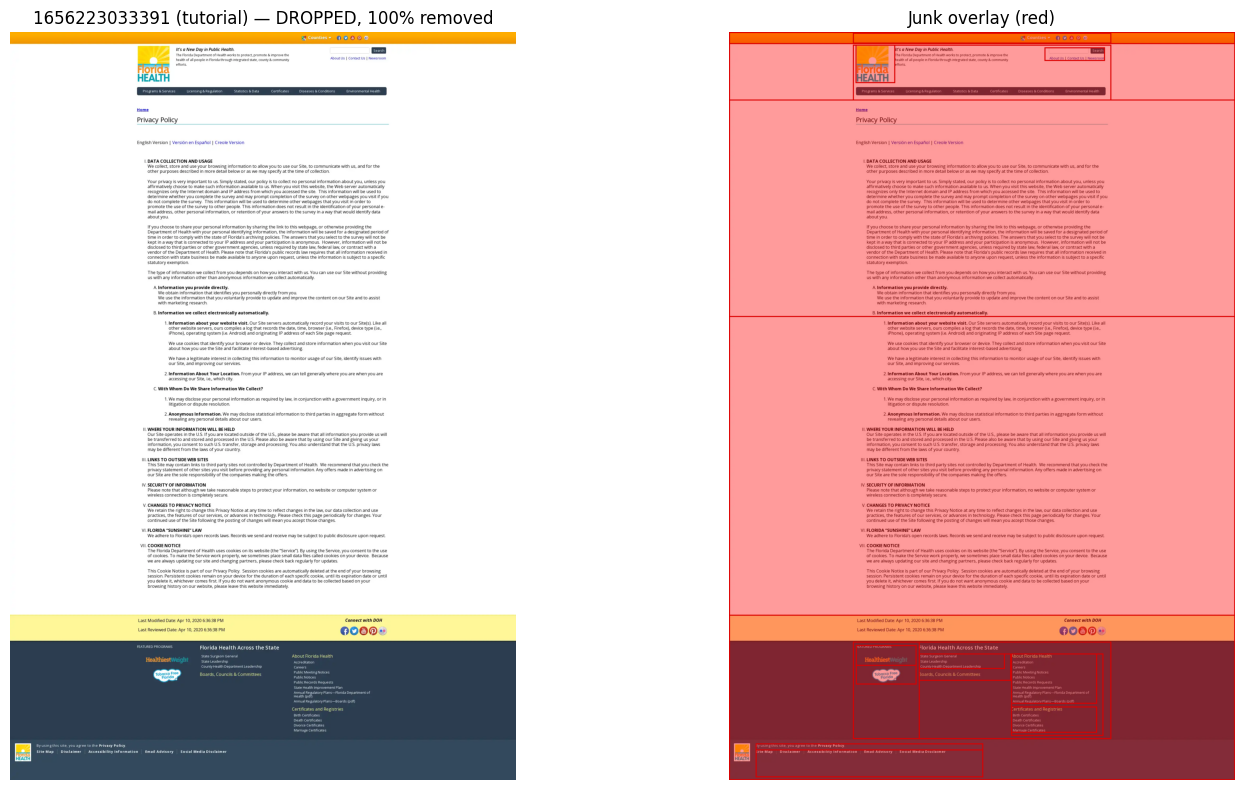

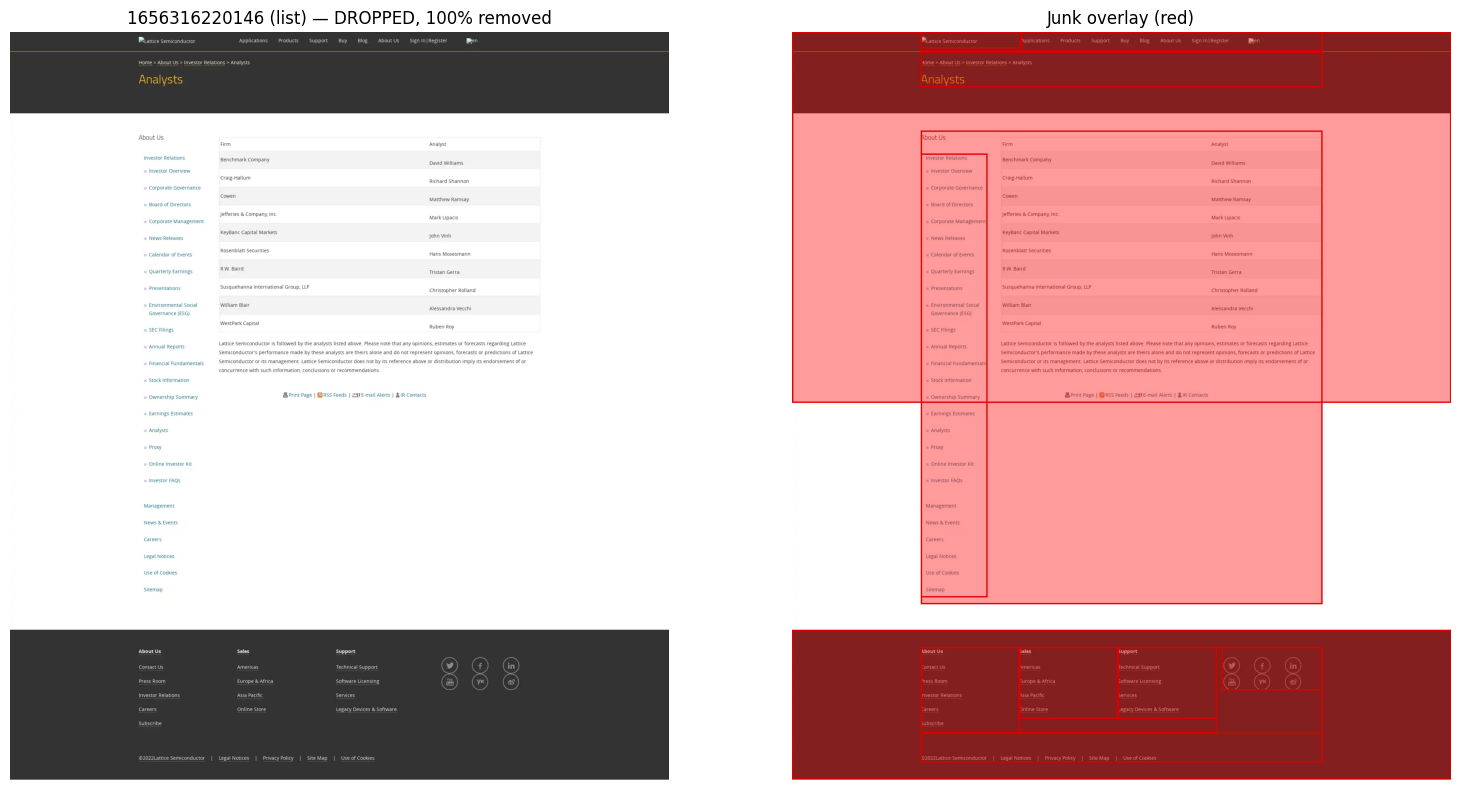

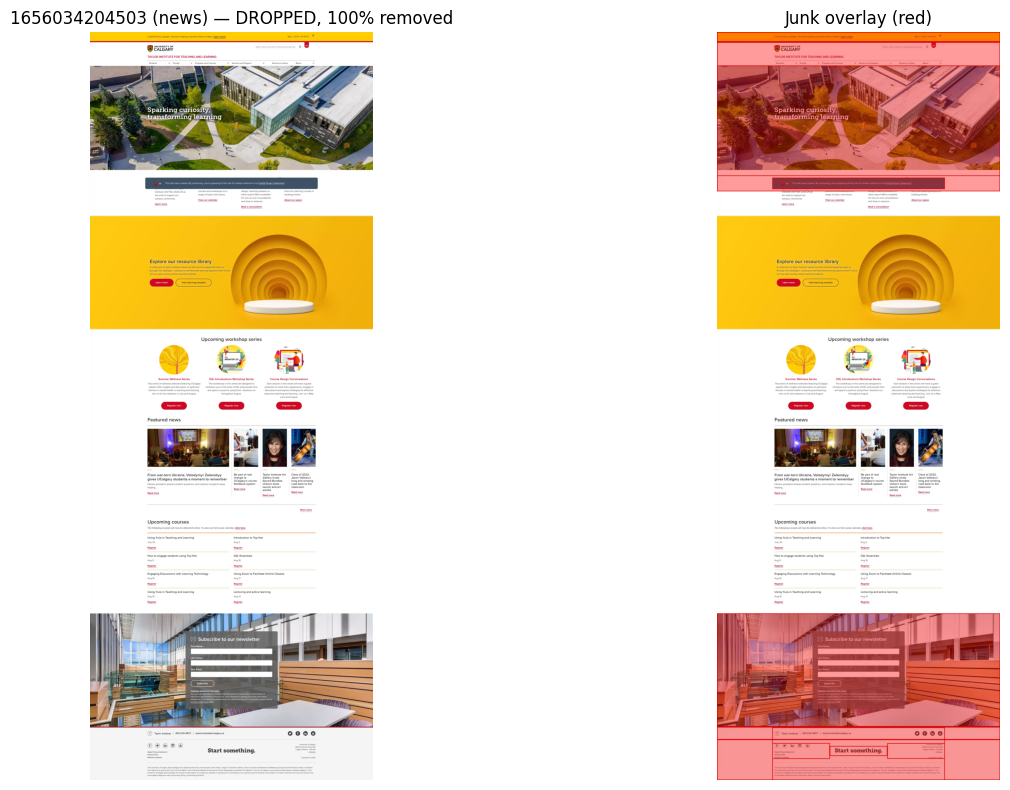

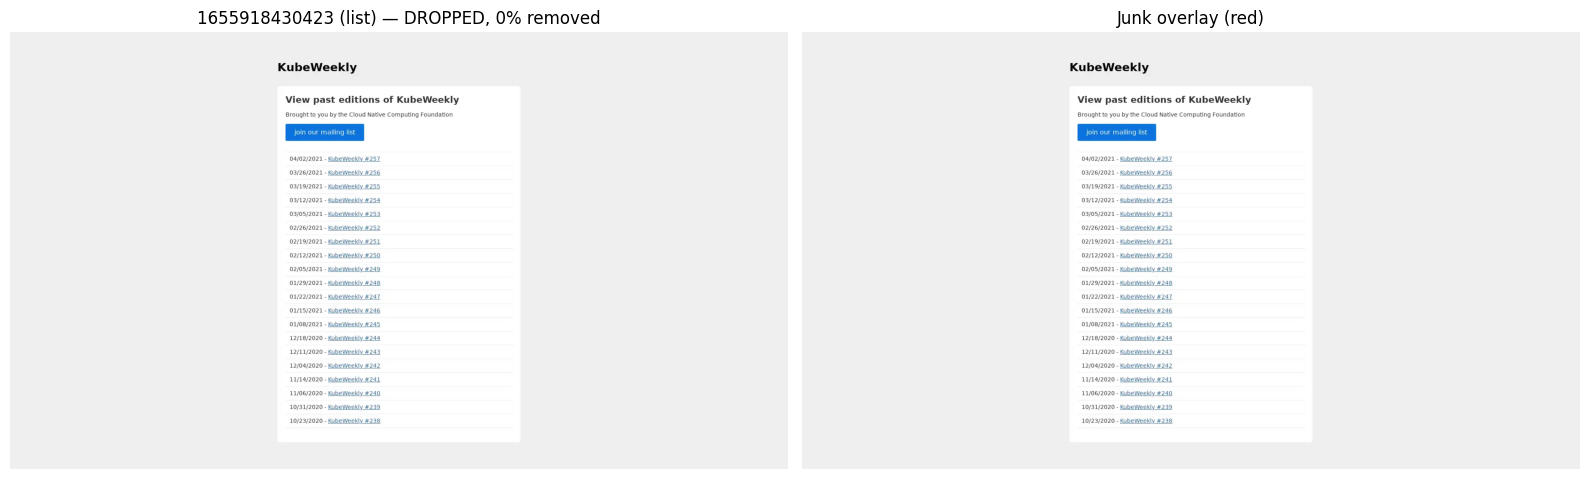

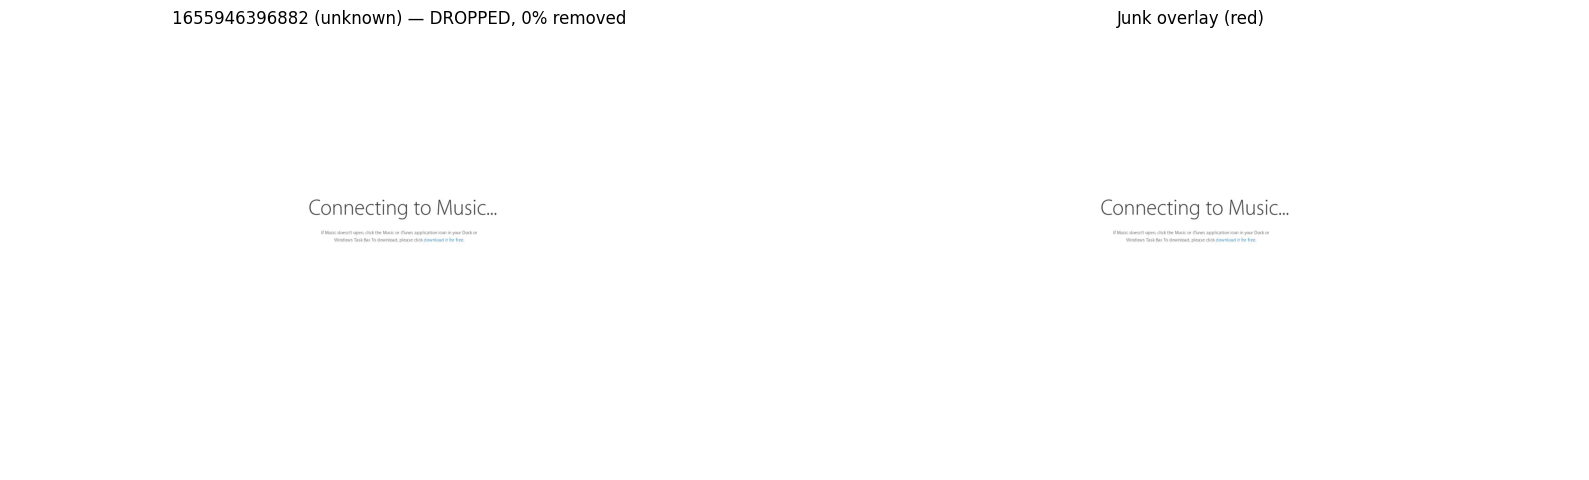

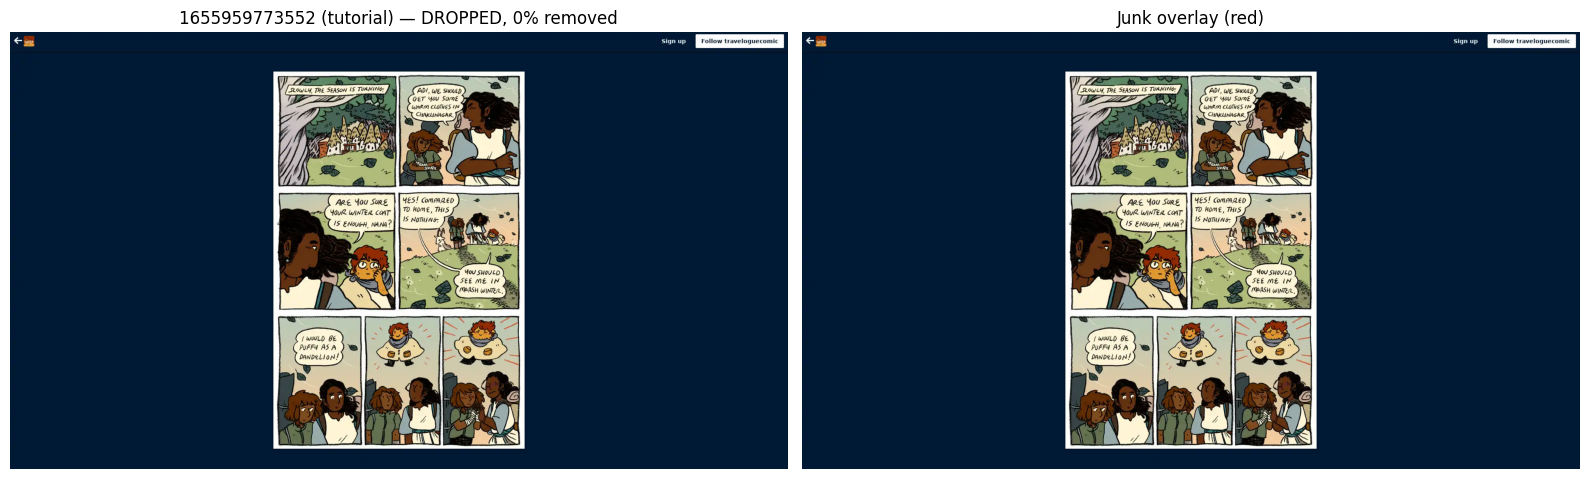

In [27]:
import random
random.seed(42)

# 3 highest-compression dropped + 3 lowest-compression dropped
high_dropped = sorted([r for r in dropped if r['compression_ratio'] > HIGH], key=lambda r: -r['compression_ratio'])[:3]
low_dropped = sorted([r for r in dropped if r['compression_ratio'] < LOW], key=lambda r: r['compression_ratio'])[:3]

demo = high_dropped + low_dropped
print(f'Visualizing {len(demo)} dropped pages...')
for r in demo:
    pid = r['page_id']
    ax_data = fa.load_page_axtree(pid)
    if ax_data is None:
        continue
    page_dir = ax_data['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None: continue
    img = Image.open(screen_path).convert('RGB')
    
    # rebuild predictions for visualization
    page_cands = candidates_by_page.get(pid, [])
    preds = fa.predict_for_page(page_cands, model, artifacts)
    junk_bboxes = [p['candidate']['bbox'] for p in preds if p['predicted_junk']]
    overlay = fv.shade_regions(img, junk_bboxes, color=(255, 0, 0), alpha=100)
    overlay = fv.draw_outlines(overlay, junk_bboxes, color=(220, 0, 0), width=4)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img); axes[0].axis('off')
    cr = r['compression_ratio'] * 100
    axes[0].set_title(f'{pid} ({r["topic"]}) — DROPPED, {cr:.0f}% removed')
    axes[1].imshow(overlay); axes[1].axis('off')
    axes[1].set_title('Junk overlay (red)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'dropped_{pid}_cr{int(cr):03d}.png', dpi=80, bbox_inches='tight')
    plt.show()

## 10. Summary

Все артефакты — `figures/cleanup/`:
- `all_pages_compression.json` — per-page compression на всём corpus
- `compression_distribution.png` — histogram + cumulative
- `cleanup_stats.json` — числа для thesis text
- `dropped_*.png` — visualization выбракованных pages

Если cleaned F1 заметно выше full F1 — значит self-consistency filter валиден и стоит внести в thesis как **«post-hoc page-level filter via classifier self-consistency»**.